In [1]:
#importing useful python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
# Sklearn tools
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay,precision_score, recall_score, f1_score
#from sklearn.model_selection import cross_val_score

# XGBoost
from xgboost import XGBClassifier


In [2]:
# dataset
positives=pd.read_csv('lightcurve_features_26.csv')
negatives=pd.read_csv('lightcurve_features_26_negative.csv')

In [3]:
combined = pd.concat([positives,negatives])
# Shuffle the combined dataset
combined = combined.sample(frac=1)#.reset_index(drop=True)
combined.to_parquet("biggie_set_with_all_neg_and_pos.parquet", index=False)

print("Combined and shuffled dataset saved")
print("Total rows:", len(combined))

Combined and shuffled dataset saved
Total rows: 1610


In [4]:
x=1471+139
print('x=',x)

x= 1610


In [5]:
df=pd.read_parquet("biggie_set_with_all_neg_and_pos.parquet")

In [6]:
df

,object,mean,weighted_mean,standard_deviation,median,amplitude,beyond_1_std,cusum,inter_percentile_range_10,kurtosis,...,magnitude_percentage_ratio_20_10,maximum_slope,median_absolute_deviation,median_buffer_range_percentage_10,percent_amplitude,mean_variance,anderson_darling_normal,chi2,skew,stetson_K
0,ZTF17aacthvn,14.148630,14.155343,0.320863,14.162024,0.923907,0.603193,0.455986,0.726996,-1.640997,...,0.959483,402.703562,0.314962,0.105263,1.293087,0.022678,155.465435,1039.839203,-0.088731,0.931915
1,ZTF18aaxmzzf,14.925270,14.789390,0.870527,15.207014,1.608598,0.310944,0.295511,2.023453,-1.294161,...,0.888693,204.711753,0.483140,0.041112,1.990362,0.058326,91.787159,4232.321034,-0.411153,0.903429
2,ZTF18abaqzzn,15.719470,15.715493,0.133000,15.666653,0.784038,0.255235,0.254032,0.298889,6.246670,...,0.759570,415.543275,0.050190,0.595359,1.301304,0.008461,72.001373,69.984650,1.461970,0.817446
3,ZTF18aaxltdi,14.261978,14.261406,0.141187,14.237264,1.053531,0.476738,0.384745,0.329399,9.286803,...,0.869149,537.134237,0.127501,0.400109,1.696994,0.009900,64.451804,96.174650,0.902084,0.883010
4,ZTF19aasmbfc,16.173631,16.169352,0.108088,16.176853,0.560873,0.435556,0.395516,0.272825,-0.065159,...,0.805805,416.812502,0.102375,0.277460,0.681433,0.006683,28.848790,45.168361,0.228269,0.869370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,ZTF18aaxysyv,15.496267,15.486970,0.180459,15.531833,0.698664,0.404942,0.237106,0.477903,-0.251890,...,0.754006,1511.988814,0.140935,0.342485,0.732155,0.011645,42.779275,148.734898,-0.383094,0.822754
1606,J0227+1306,17.721894,17.248713,0.856176,17.412321,2.219775,0.262712,0.276740,2.174030,1.174774,...,0.626204,1368.534159,0.333530,0.341808,3.422985,0.048312,36.474922,433.287793,1.294503,0.823548
1607,ZTF18adjzodz,16.028857,15.550835,1.300101,15.737716,2.309861,0.461231,0.249115,3.729522,-1.053045,...,0.784707,1483.587099,1.056531,0.345496,2.684480,0.081110,57.836455,3729.293629,0.280151,0.835988
1608,ZTF18adkbjjt,16.505816,16.128047,0.990430,16.564083,2.261654,0.388002,0.152161,2.927744,-0.352601,...,0.636331,369.161440,0.500095,0.396258,2.461342,0.060005,48.399369,2596.098313,-0.341340,0.840141


In [7]:
#X
X = df.drop(columns=['object']).values

In [8]:
# object column contains names like 'ZTF18abc...' or non-ZTF names : Binary conversion of objects
y = np.where(df['object'].str.contains('ZTF', case=False),
             -1,   # ZTF → negative
              1)   # non-ZTF → positive

In [9]:
print(np.unique(y))


[-1  1]


In [10]:
#doing this as XGBBOOST can't deal with -1 and 1
y[y == -1] = 0


In [11]:
print(np.unique(y))


[0 1]


In [12]:
SEED = 12

train_sizes = np.arange(0.5, 0.91, 0.1)   # train size
n_estimators = np.arange(50, 201, 20)      # number of trees

results = []

for size in train_sizes:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        train_size=size,
        shuffle=True,
        random_state=SEED,
        stratify=y
    )

    for n in n_estimators:

        # XGBoost model
        model = XGBClassifier(
            n_estimators=n,
            max_depth=10,       # fixed
            learning_rate=0.3,  # default
            eval_metric='logloss'
        )

        # Model fitting
        model.fit(X_train, y_train)

        # Prediction
        y_pred = model.predict(X_test)

        # Evaluation
        acc = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, pos_label=1)
        recall = recall_score(y_test, y_pred, pos_label=1)
        f1 = f1_score(y_test, y_pred, pos_label=1)

        # Store results
        results.append({
            "train_size": size,
            "n_estimators": n,
            "max_depth": 10,
            "learning_rate": 0.3,
            "accuracy": acc,
            "precision": precision,
            "recall": recall,
            "f1_score": f1
        })

results_df = pd.DataFrame(results)

In [13]:
#check
results_df

,train_size,n_estimators,max_depth,learning_rate,accuracy,precision,recall,f1_score
0,0.5,50,10,0.3,0.961491,0.800000,0.742857,0.770370
1,0.5,70,10,0.3,0.961491,0.800000,0.742857,0.770370
2,0.5,90,10,0.3,0.959006,0.784615,0.728571,0.755556
3,0.5,110,10,0.3,0.959006,0.784615,0.728571,0.755556
4,0.5,130,10,0.3,0.959006,0.784615,0.728571,0.755556
5,0.5,150,10,0.3,0.960248,0.787879,0.742857,0.764706
6,0.5,170,10,0.3,0.960248,0.787879,0.742857,0.764706
7,0.5,190,10,0.3,0.960248,0.787879,0.742857,0.764706
8,0.6,50,10,0.3,0.950311,0.706897,0.732143,0.719298
9,0.6,70,10,0.3,0.950311,0.706897,0.732143,0.719298


In [14]:
# Find best configuration based on recall
best_row = results_df.loc[results_df["precision"].idxmax()]

best_train_size = best_row["train_size"]
best_n_estimators = best_row["n_estimators"]
best_max_depth = best_row["max_depth"]
best_learning_rate = best_row["learning_rate"]

best_accuracy = best_row["accuracy"]
best_precision = best_row["precision"]
best_recall = best_row["recall"]
best_f1 = best_row["f1_score"]

print("Best configuration based on precision:")
print(f"Train size       : {best_train_size}")
print(f"n_estimators     : {best_n_estimators}")
print(f"max_depth        : {best_max_depth}")
print(f"learning_rate    : {best_learning_rate}")
print(f"Test accuracy    : {best_accuracy:.4f}")
print(f"Test precision   : {best_precision:.4f}")
print(f"Test recall      : {best_recall:.4f}")
print(f"Test F1-score    : {best_f1:.4f}")

Best configuration based on precision:
Train size       : 0.5
n_estimators     : 50.0
max_depth        : 10.0
learning_rate    : 0.3
Test accuracy    : 0.9615
Test precision   : 0.8000
Test recall      : 0.7429
Test F1-score    : 0.7704


In [15]:
best_accuracy = results_df["accuracy"].max()

best_rows = results_df[results_df["accuracy"] == best_accuracy]

print(best_rows)
best_rows.to_csv('best_configuration_RS_12_1.csv')

    train_size  n_estimators  max_depth  learning_rate  accuracy  precision  \
21         0.7           150         10            0.3  0.962733        0.8   

      recall  f1_score  
21  0.761905  0.780488  


In [16]:
#train the best model
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=best_train_size,
    #stratify=y,
   random_state=12
)
#best model with best parameters
best_model = XGBClassifier(
    n_estimators=int(best_n_estimators),
    max_depth=int(best_max_depth),
    learning_rate=float(best_learning_rate),
    eval_metric='logloss',
    n_jobs=-1
)
#fit best model
best_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=-1,
              num_parallel_tree=None, ...)

In [17]:
#predict model
y_pred = best_model.predict(X_test)
print(y_pred)


[0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 

In [18]:
#accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
#precision
print("Precision:", precision_score(y_test, y_pred))


Accuracy: 0.9540372670807453
Precision: 0.9090909090909091


In [19]:
probs = best_model.predict_proba(X_test)
#print('probs',probs)

Confusion matrix (raw counts):
[[718   5]
 [ 32  50]]


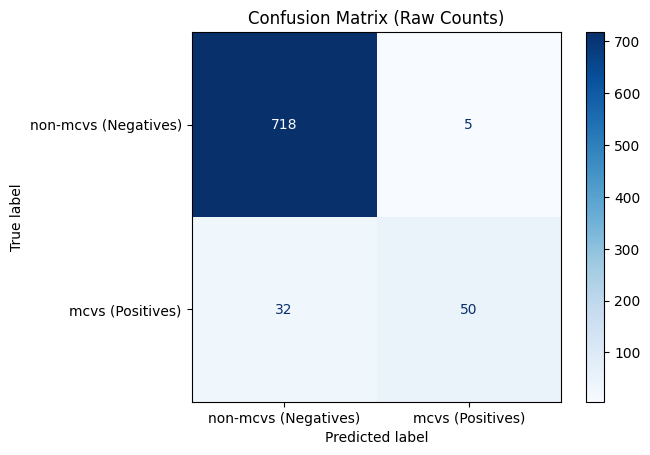

In [20]:
# For best model CONFUSION MATRIX + TP / TN / FP / FN IDENTIFICATION
# Class labels for clarity
class_names = ["non-mcvs (Negatives)", "mcvs (Positives)"]

# Plot confusion matrix (raw counts)
disp = ConfusionMatrixDisplay.from_estimator(
   best_model,
    X_test,
    y_test,
    display_labels=class_names,
    cmap=plt.cm.Blues #heatmap
)

disp.ax_.set_title("Confusion Matrix (Raw Counts)")
print("Confusion matrix (raw counts):")
print(disp.confusion_matrix)

plt.show()


# Extract TN, FP, FN, TP explicitly
# Label convention used in  code:
#   0 :ZTF names (negative, non-CV)
#   +1 :non-ZTF names (positive, CV)

cm = confusion_matrix(y_test, best_model.predict(X_test), labels=[0, 1])

TN, FP, FN, TP = cm.ravel()

In [21]:
#saving the best model
joblib.dump(best_model, "cv_classifier_best_model_12_1.pkl")

['cv_classifier_best_model_12_1.pkl']

In [22]:
#from this cell our prev work
# last used hyperparameters
train_size = 0.70
n_estimators = 50
#oter parameters were not varied
# Final train-test split
X_train_prev, X_test_prev, y_train_prev, y_test_prev = train_test_split(
    X,
    y,
    train_size=0.70,
    shuffle=True,
    random_state=12
)

# Train final model
final_model =  XGBClassifier(
    n_estimators=50,
    n_jobs=-1,
    learning_rate=0.1, #Learning rate shrinks the contribution of each tree,Values must be in the range [0.0, inf),values by default float, default=0.1
    max_depth=3, #max_depthint or None, default=3
    eval_metric='logloss' 
)

final_model.fit(X_train_prev, y_train_prev)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=-1,
              num_parallel_tree=None, ...)

In [23]:
#training set
final_model.fit(X_train_prev, y_train_prev)

print("Model trained successfully")


Model trained successfully


In [24]:
#predict model
y_pred = final_model.predict(X_test_prev)
print(y_pred)


[0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 1 0 1 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0
 0 0]


In [25]:
#accuracy
print("Accuracy:", accuracy_score(y_test_prev, y_pred))


Accuracy: 0.968944099378882


In [26]:
probs = best_model.predict_proba(X_test_prev)
print('probs',probs)

probs [[9.99717712e-01 2.82276713e-04]
 [9.99613345e-01 3.86637636e-04]
 [9.99865651e-01 1.34333910e-04]
 [9.99698699e-01 3.01294087e-04]
 [1.13501549e-02 9.88649845e-01]
 [9.99837339e-01 1.62675744e-04]
 [9.99716282e-01 2.83722358e-04]
 [9.98555720e-01 1.44428946e-03]
 [9.52290416e-01 4.77096103e-02]
 [9.99380708e-01 6.19264145e-04]
 [9.93028522e-01 6.97149569e-03]
 [4.60249901e-01 5.39750099e-01]
 [9.95007932e-01 4.99203941e-03]
 [9.98735845e-01 1.26412872e-03]
 [9.99898851e-01 1.01157711e-04]
 [9.99011099e-01 9.88922897e-04]
 [9.88724291e-01 1.12757282e-02]
 [9.99656200e-01 3.43804044e-04]
 [9.99416530e-01 5.83493093e-04]
 [6.30507529e-01 3.69492471e-01]
 [9.98931706e-01 1.06827472e-03]
 [9.99782085e-01 2.17895446e-04]
 [9.98585045e-01 1.41497434e-03]
 [9.99790430e-01 2.09540973e-04]
 [9.99192834e-01 8.07163189e-04]
 [9.99076188e-01 9.23814601e-04]
 [9.93785203e-01 6.21477468e-03]
 [9.98681784e-01 1.31822971e-03]
 [9.98542547e-01 1.45742460e-03]
 [9.99574542e-01 4.25485894e-04]
 [9.

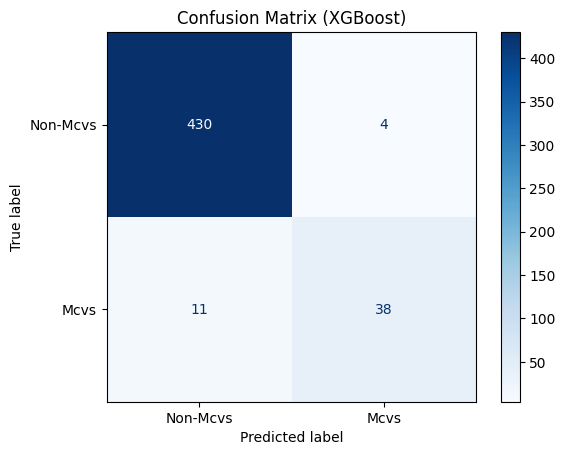

In [27]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test_prev, y_pred, labels=[0, 1])

class_names = ["Non-Mcvs", "Mcvs"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (XGBoost)")
# Save the figure to current directory
#plt.savefig('confusion matrix_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
#extract TP, TN, FP, FN
TN, FP, FN, TP = cm.ravel()
print("TN:", TN, "FP:", FP, "FN:", FN, "TP:", TP)

TN: 430 FP: 4 FN: 11 TP: 38


In [29]:
#saving the final model
joblib.dump(final_model, "cv_classifier_xgb_boost_biggie_set_12_1.pkl")

['cv_classifier_xgb_boost_biggie_set_12_1.pkl']